
# Compound scenario & trained-policy analysis

Prepared 2026-09-18. Covers:

- **A.** The `compound_scenario` chain scenario: its 13 phases, job counts, and the
  mechanics behind each phase type.
- **B.** How each of the 9 dispatching-priority rules (PDRs) behaves across the full
  scenario — work-in-progress, time-in-system, and throughput over sim-time.
- **C.** The trained RL policy (`results/ep_warmup01/checkpoint.pt`, 999,848 training
  steps) against the PDR baselines on the same instance.
- **D.** What the trained policy is actually *doing* — its chosen rule, confidence, and
  full action distribution over the course of one full episode.

See `docs/RL_TRAINING_PIPELINE.md` (esp. §8-11) for the full narrative and the
9-seed held-out aggregate evaluation this notebook's single-instance view complements.


In [1]:

import csv, json
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "linux_server").exists(), "run from repo root"

RULES_ORDER = ["FIFO_SRWT", "SPT_SRWT", "SPT_SMPT", "LPT_SMPT", "LRT_MMUR",
               "LPT_MMUR", "SRT_SRWT", "SRT_SMPT", "random"]
COLORS = dict(zip(RULES_ORDER, cm.tab10(np.linspace(0, 1, len(RULES_ORDER)))))
plt.rcParams["figure.dpi"] = 110



## A. The `compound_scenario` chain scenario

A single hand-crafted, deterministic instance (`linux_server/BatchConfigs/Scenarios/compound_scenario.json`,
seed 42) — not i.i.d.-random job generation. 13 phases chained end-to-end, each a
different *regime* a real job shop might sustain for a while: quiet baseline, a pinned
single-machine bottleneck, a two-machine contested standoff, a sudden arrival burst, and
a long-job-starvation stream. Bottleneck and standoff each appear **twice**, so a rule's
second encounter with the same regime can be compared against its first.


In [2]:

scenario = json.load(open(REPO_ROOT / "linux_server/BatchConfigs/Scenarios/compound_scenario.json"))
jobs = scenario["jobs"]
phases = scenario["_phases"]

print(f"Total jobs: {len(jobs)}   Total phases: {len(phases)}   "
      f"AGVs: {scenario['agvCount']}   Machines: {len(scenario['machineTypeLayout'])}")
print(f"Machine layout: {scenario['machineTypeLayout']}")
print(f"Total scenario span: {phases[-1]['end']:.0f}s (~{phases[-1]['end']/3600:.2f} hours sim-time)")

phase_kind = {
    "quiet": "Light background load, Mill/Lathe/Inspect only (never touches the "
             "bottleneck machine) -- a genuine recovery baseline between stress phases.",
    "bottleneck": "All jobs route through Mill then a single PINNED Weld machine "
                  "(index 1). Job count sized from target utilization (0.85) so pressure "
                  "sustains for the whole phase, not a spike that drains in seconds.",
    "standoff": "Mill then a contested 2-machine Weld subset (indices 0,1); each job's "
                "two candidate machines have a genuinely different cost (1.3-2x apart, "
                "randomly which one) -- tests whether routing finds the truly cheaper one.",
    "burst": "A deliberate shock: all jobs land within ~5 seconds. Meant to overflow its "
             "nominal window -- the interesting part is how long recovery takes after.",
    "starvation": "3 long jobs (180s) arrive first, then 80 short jobs (~12s) stream in "
                  "faster (~5s apart) than one machine can drain them -- the queue never "
                  "empties, so SPT-family rules defer the long jobs for the whole stream.",
}
def kind_of(name):
    for k in phase_kind:
        if name.startswith(k):
            return k
    return "quiet"

rows = []
for p in phases:
    k = kind_of(p["name"])
    rows.append({
        "phase": p["name"], "kind": k, "start": p["start"], "end": p["end"],
        "span_s": p["end"] - p["start"], "n_jobs": p["n_jobs"],
        "mechanic": phase_kind[k],
    })
phase_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
phase_df[["phase", "start", "end", "span_s", "n_jobs", "mechanic"]]


Total jobs: 383   Total phases: 13   AGVs: 7   Machines: 15
Machine layout: ['Mill', 'Mill', 'Mill', 'Lathe', 'Lathe', 'Lathe', 'Weld', 'Weld', 'Weld', 'Inspect', 'Inspect', 'Inspect', 'Assemble', 'Assemble', 'Assemble']
Total scenario span: 11255s (~3.13 hours sim-time)


,phase,start,end,span_s,n_jobs,mechanic
0,quiet_1,0.0,400.0,400.0,15,"Light background load, Mill/Lathe/Inspect only (never touches the bottleneck..."
1,bottleneck_1,450.0,2250.0,1800.0,27,All jobs route through Mill then a single PINNED Weld machine (index 1). Job...
2,quiet_2,2300.0,2700.0,400.0,12,"Light background load, Mill/Lathe/Inspect only (never touches the bottleneck..."
3,standoff_1,2750.0,4550.0,1800.0,63,"Mill then a contested 2-machine Weld subset (indices 0,1); each job's two ca..."
4,quiet_3,4600.0,5000.0,400.0,12,"Light background load, Mill/Lathe/Inspect only (never touches the bottleneck..."
5,burst_1,5050.0,5055.0,5.0,30,A deliberate shock: all jobs land within ~5 seconds. Meant to overflow its n...
6,quiet_4,5350.0,5750.0,400.0,12,"Light background load, Mill/Lathe/Inspect only (never touches the bottleneck..."
7,starvation_1,5800.0,6205.0,405.0,83,"3 long jobs (180s) arrive first, then 80 short jobs (~12s) stream in faster ..."
8,quiet_5,6255.0,6655.0,400.0,12,"Light background load, Mill/Lathe/Inspect only (never touches the bottleneck..."
9,bottleneck_2,6705.0,8505.0,1800.0,27,All jobs route through Mill then a single PINNED Weld machine (index 1). Job...


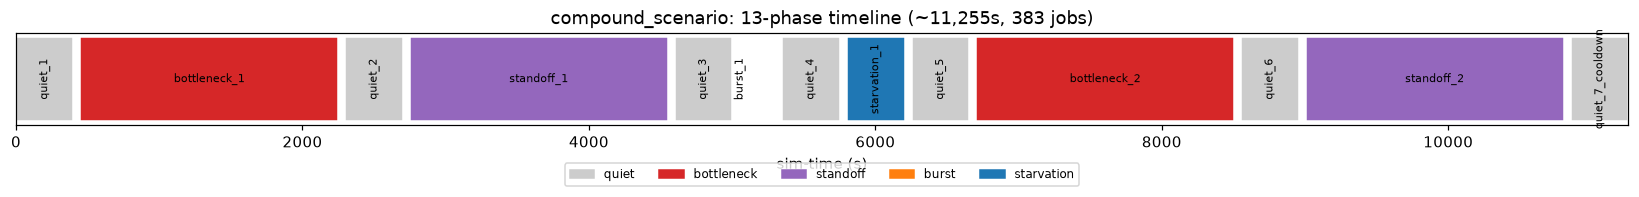

In [3]:

# Gantt-style timeline of phases, colored by regime kind
kind_colors = {"quiet": "#cccccc", "bottleneck": "#d62728", "standoff": "#9467bd",
               "burst": "#ff7f0e", "starvation": "#1f77b4"}
fig, ax = plt.subplots(figsize=(15, 2.2))
for _, r in phase_df.iterrows():
    ax.barh(0, r["span_s"], left=r["start"], height=0.6,
            color=kind_colors[r["kind"]], edgecolor="white")
    ax.annotate(r["phase"], (r["start"] + r["span_s"] / 2, 0), ha="center", va="center",
                fontsize=7, rotation=0 if r["span_s"] > 700 else 90)
ax.set_xlim(0, phase_df["end"].max())
ax.set_yticks([])
ax.set_xlabel("sim-time (s)")
ax.set_title("compound_scenario: 13-phase timeline (~11,255s, 383 jobs)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in kind_colors.values()]
ax.legend(handles, kind_colors.keys(), loc="upper center", bbox_to_anchor=(0.5, -0.35),
          ncol=5, fontsize=8)
fig.tight_layout()
plt.show()



- **bottleneck** (red) — every job pinned to one Weld machine, sized to sustain ~85% utilization for the whole phase.
- **standoff** (purple) — every job contests 2 Weld machines with a genuinely different cost each, testing whether routing picks the cheaper one.
- **burst** (orange) — all 30 jobs arrive within ~5 seconds, a deliberate shock; the point is watching recovery afterward.
- **starvation** (blue) — 3 long jobs land first, then a short-job stream faster than one machine can drain — SPT-family rules defer the long jobs for the entire stream.


In [4]:

op_counts = [len(j["operations"]) for j in jobs]
durs = []
for j in jobs:
    for op in j["operations"]:
        d = op["duration"]
        durs.extend(d if isinstance(d, list) else [d])
print(f"Ops per job: {min(op_counts)}-{max(op_counts)}")
print(f"Op durations (sim-seconds): min={min(durs):.1f} max={max(durs):.1f} mean={np.mean(durs):.1f}")
print(f"\nJobs per phase (min/max/mean across the 13 phases): "
      f"{phase_df['n_jobs'].min()} / {phase_df['n_jobs'].max()} / {phase_df['n_jobs'].mean():.1f}")


Ops per job: 1-2
Op durations (sim-seconds): min=10.8 max=180.0 mean=34.6

Jobs per phase (min/max/mean across the 13 phases): 12 / 83 / 29.5



## B. PDR behavior across the full scenario

Batch-runner data (`results/static_pdrs/0911a/job_completions.csv`): all 9 PDR rules run on this same
instance, 3 repeats each (repeats only vary AGV-assignment tie-breaks and the `random`
rule's own draws -- the job arrival schedule itself is identical every repeat, since
`compound_scenario`'s job set is explicit in the JSON, not regenerated from the seed). One
repeat is used per rule below to avoid triple-weighting the series.


In [5]:

def load_job_completions(results_dir, instance_name="compound_scenario"):
    rows = []
    with open(Path(results_dir) / "job_completions.csv", newline="") as f:
        for r in csv.DictReader(f):
            if r["instance"] != instance_name:
                continue
            completed = r["completed"] in ("1", "True")
            # "random" vs "Random": casing is inconsistent across batch runs (v1 data has
            # lowercase, v2 has PascalCase matching the C# enum's ToString()) -- normalize so
            # RULES_ORDER's lowercase "random" matches either.
            rule = r["rule"]
            if rule.lower() == "random":
                rule = "random"
            rows.append({
                "rule": rule, "seed": r["seed"],
                "arrival": float(r["arrival_time"]),
                "exit": float(r["exit_time"]) if completed else None,
                "flow": float(r["flow_time"]) if completed else None,
            })
    return rows

def first_seed_only(rows):
    if not rows:
        return rows
    seed = sorted(set(r["seed"] for r in rows))[0]
    return [r for r in rows if r["seed"] == seed]

pdr_rows = load_job_completions(REPO_ROOT / "results/static_pdrs/0911a")
pdr_by_rule = defaultdict(list)
for r in pdr_rows:
    pdr_by_rule[r["rule"]].append(r)
print({rule: len(first_seed_only(pdr_by_rule.get(rule, []))) for rule in RULES_ORDER})


{'FIFO_SRWT': 383, 'SPT_SRWT': 383, 'SPT_SMPT': 383, 'LPT_SMPT': 383, 'LRT_MMUR': 383, 'LPT_MMUR': 383, 'SRT_SRWT': 383, 'SRT_SMPT': 383, 'random': 383}


In [6]:

def rolling_wip(rows, t_max, window=200.0, step=25.0):
    centers = np.arange(window / 2, t_max + step, step)
    wip = np.zeros_like(centers)
    for j in rows:
        start, end = j["arrival"], j["exit"] if j["exit"] is not None else t_max
        lo = np.maximum(centers - window / 2, start)
        hi = np.minimum(centers + window / 2, end)
        wip += np.clip(hi - lo, 0, None) / window
    return centers, wip

def rolling_flowtime(rows, t_max, window=300.0, step=50.0):
    centers = np.arange(window / 2, t_max + step, step)
    result = np.full_like(centers, np.nan)
    exits = [(j["exit"], j["flow"]) for j in rows if j["exit"] is not None]
    for i, c in enumerate(centers):
        lo, hi = c - window / 2, c + window / 2
        vals = [f for e, f in exits if lo <= e < hi]
        if vals:
            result[i] = sum(vals) / len(vals)
    return centers, result

def rolling_throughput(rows, t_max, window=300.0, step=50.0):
    # Jobs completed per second, in a sliding window -- the flow-rate view.
    centers = np.arange(window / 2, t_max + step, step)
    exits = [j["exit"] for j in rows if j["exit"] is not None]
    result = np.zeros_like(centers)
    for i, c in enumerate(centers):
        lo, hi = c - window / 2, c + window / 2
        result[i] = sum(1 for e in exits if lo <= e < hi) / window
    return centers, result

def shade_phases(ax, phases, y_top):
    for i, p in enumerate(phases):
        ax.axvspan(p["start"], p["end"], color="gray", alpha=0.10 if i % 2 == 0 else 0.18)

def plot_overlay(rows_by_rule, phases, t_max, series_fn, ylabel, title, rules=RULES_ORDER,
                  **kw):
    fig, ax = plt.subplots(figsize=(15, 5.5))
    y_max = 0
    for rule in rules:
        rows = first_seed_only(rows_by_rule.get(rule, []))
        if not rows:
            continue
        xs, ys = series_fn(rows, t_max, **kw)
        ax.plot(xs, ys, label=rule, color=COLORS.get(rule, "black"), linewidth=1.4, alpha=0.9)
        finite = ys[np.isfinite(ys)]
        if finite.size:
            y_max = max(y_max, finite.max())
    shade_phases(ax, phases, y_max * 1.02 if y_max > 0 else 1.0)
    ax.set_xlabel("sim-time (s)"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8, ncol=3)
    fig.tight_layout()
    plt.show()

t_max = phases[-1]["end"] + 300.0


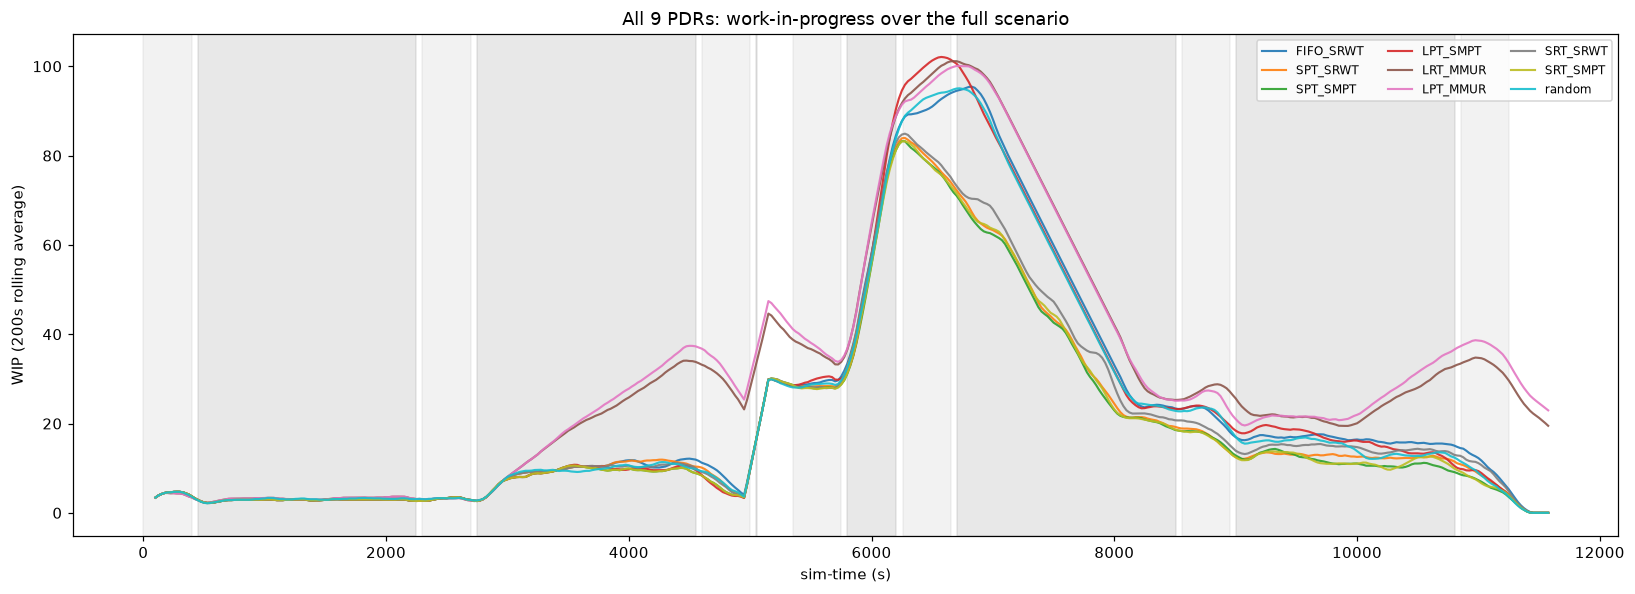

In [7]:

plot_overlay(pdr_by_rule, phases, t_max, rolling_wip,
             ylabel="WIP (200s rolling average)",
             title="All 9 PDRs: work-in-progress over the full scenario")


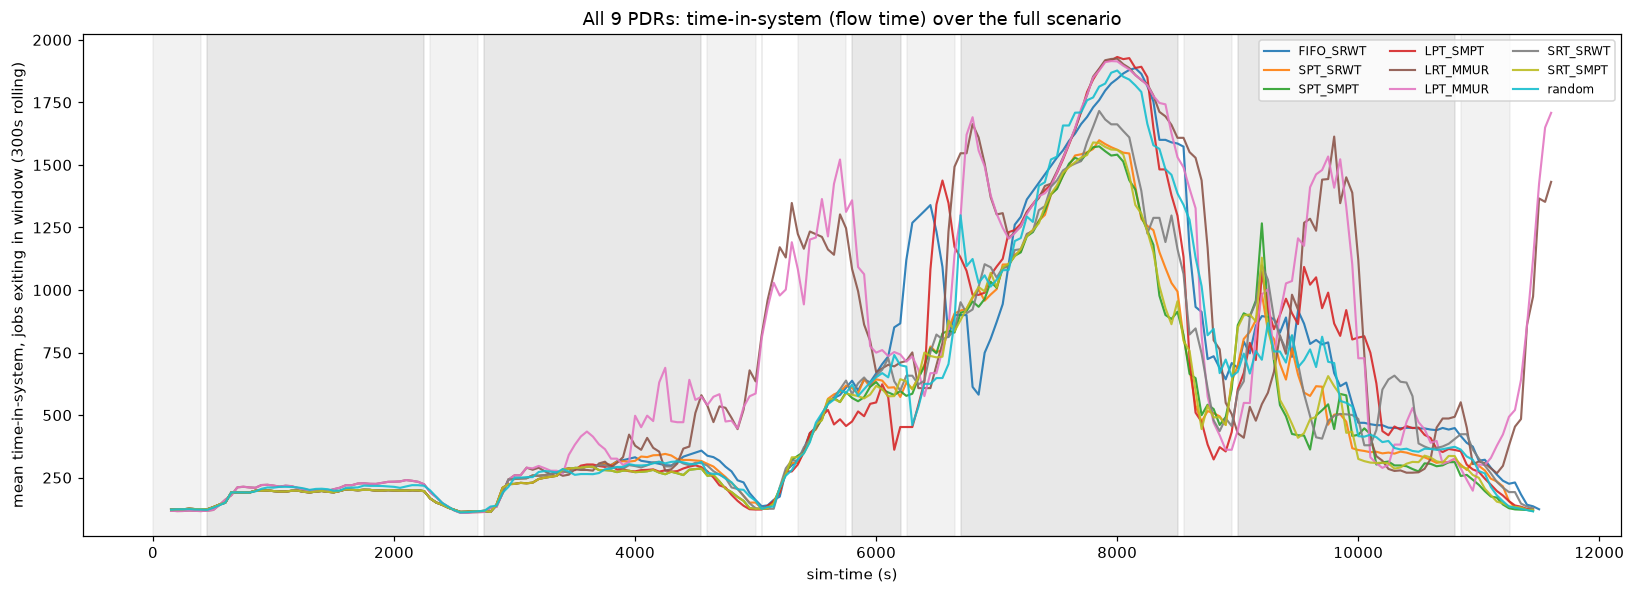

In [8]:

plot_overlay(pdr_by_rule, phases, t_max, rolling_flowtime,
             ylabel="mean time-in-system, jobs exiting in window (300s rolling)",
             title="All 9 PDRs: time-in-system (flow time) over the full scenario")


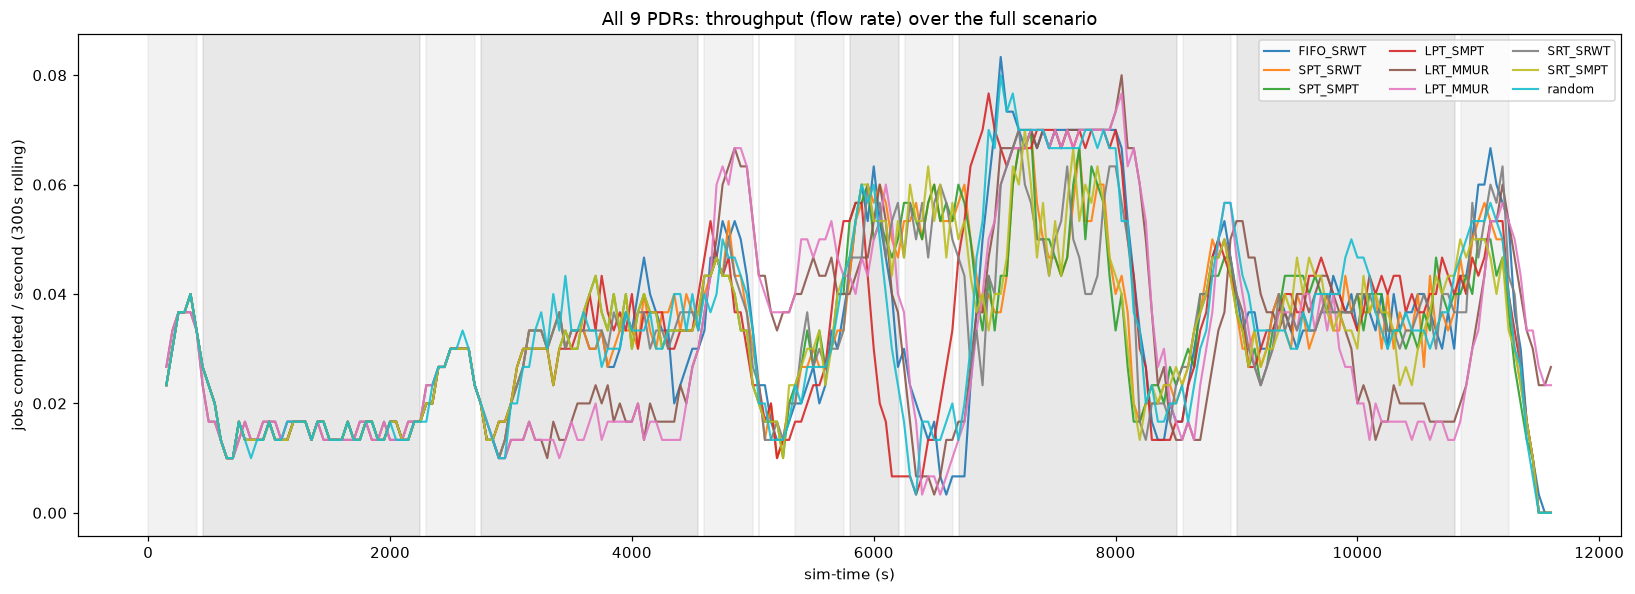

In [9]:

plot_overlay(pdr_by_rule, phases, t_max, rolling_throughput,
             ylabel="jobs completed / second (300s rolling)",
             title="All 9 PDRs: throughput (flow rate) over the full scenario")



**Reading these three together:** WIP and time-in-system both spike during `bottleneck`
and `standoff` phases and partially recede during `quiet` buffers -- but not all the way
for every rule, which is the "does a rule fully recover between stress phases, or carry
backlog forward" question these bands make visible. Throughput dips sharply during
`starvation` for the SPT-family rules specifically (they defer the long jobs for the
entire short-job stream), which is the mechanism, not just an artifact.



## C. PDRs vs. the trained policy

The trained checkpoint (`results/ep_warmup01/checkpoint.pt`) evaluated on this exact same
fixed instance via `evaluate.py --decision-log` -- so its WIP/throughput trace is directly
comparable to the PDR traces above, no re-alignment needed. This is a single-instance,
qualitative view; the precise quantitative comparison (9 held-out seeds, full statistics)
is in `docs/RL_TRAINING_PIPELINE.md` §11 -- reproduced at the end of this section.


In [10]:

decisions = pd.read_csv(REPO_ROOT / "results/ep_warmup01_decisionlog/decisions.csv")
print(f"{len(decisions)} decisions over {decisions['sim_time'].max():.0f}s")
decisions.head()


1186 decisions over 11260s


,policy,kind,seed,seed_index,step,sim_time,decision_count,wip,jobs_exited,action,...,entropy,chosen_prob,p_SPT-SMPT,p_SPT-SRWT,p_LPT-MMUR,p_LPT-SMPT,p_SRT-SRWT,p_SRT-SMPT,p_LRT-MMUR,p_FIFO-SRWT
0,ckpt:ep_warmup01/checkpoint,checkpoint,0,0,0,0.02,1,1,0,0,...,1.75685,0.29617,0.29617,0.05924,0.05196,0.22674,0.09855,0.02388,0.02356,0.21989
1,ckpt:ep_warmup01/checkpoint,checkpoint,0,0,1,26.70,2,2,0,0,...,1.73997,0.29933,0.29933,0.05525,0.05199,0.23065,0.09297,0.02217,0.02272,0.22491
2,ckpt:ep_warmup01/checkpoint,checkpoint,0,0,2,30.96,3,2,0,0,...,1.74981,0.30735,0.30735,0.05860,0.04916,0.22263,0.10257,0.02390,0.02280,0.21298
3,ckpt:ep_warmup01/checkpoint,checkpoint,0,0,3,53.36,4,3,0,0,...,1.75802,0.29079,0.29079,0.05894,0.05431,0.22853,0.09409,0.02377,0.02389,0.22568
4,ckpt:ep_warmup01/checkpoint,checkpoint,0,0,4,58.54,5,3,0,0,...,1.71590,0.28675,0.28675,0.04889,0.05604,0.24549,0.07852,0.01925,0.02212,0.24296


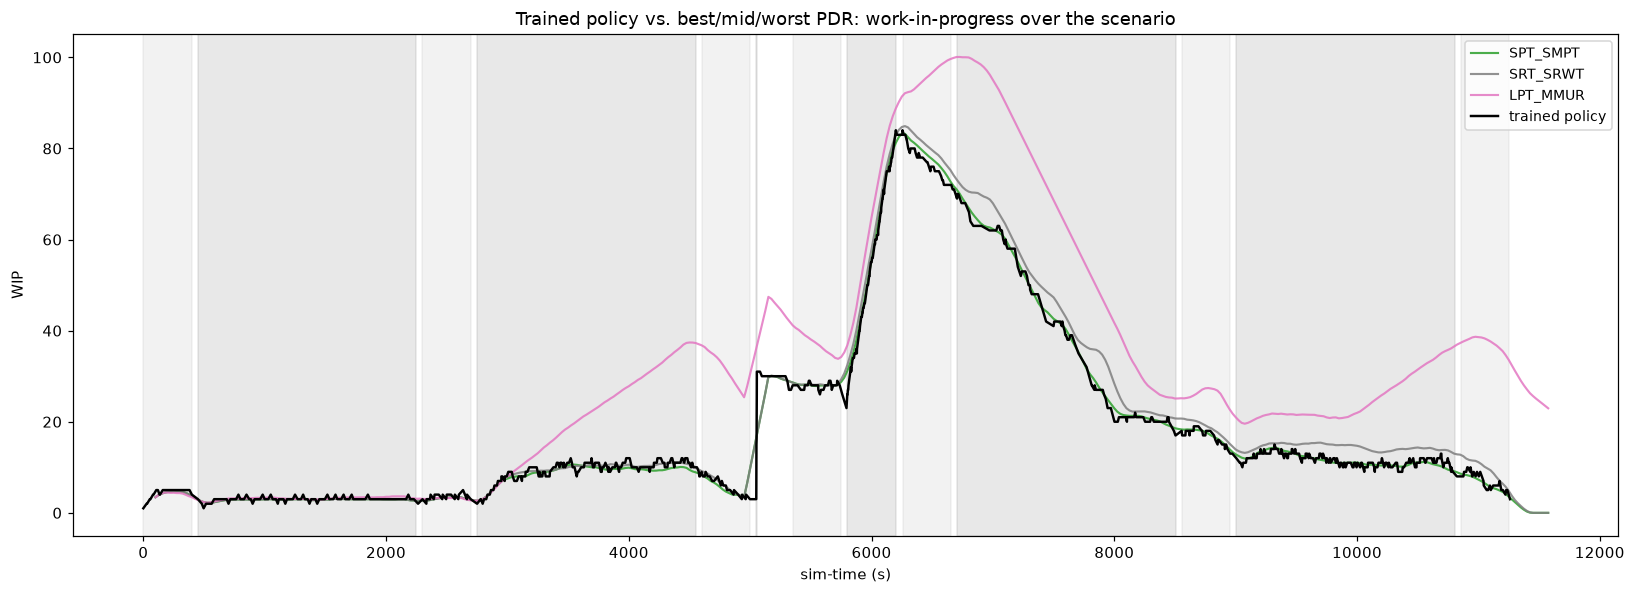

In [11]:

# Reference PDRs (best/mid/worst, to keep the plot legible) + trained policy
fig, ax = plt.subplots(figsize=(15, 5.5))
for rule in ["SPT_SMPT", "SRT_SRWT", "LPT_MMUR"]:
    rows = first_seed_only(pdr_by_rule.get(rule, []))
    xs, ys = rolling_wip(rows, t_max)
    ax.plot(xs, ys, label=rule, color=COLORS[rule], linewidth=1.4, alpha=0.85)
ax.plot(decisions["sim_time"], decisions["wip"], label="trained policy", color="black",
        linewidth=1.6)
shade_phases(ax, phases, decisions["wip"].max() * 1.05)
ax.set_xlabel("sim-time (s)"); ax.set_ylabel("WIP")
ax.set_title("Trained policy vs. best/mid/worst PDR: work-in-progress over the scenario")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()


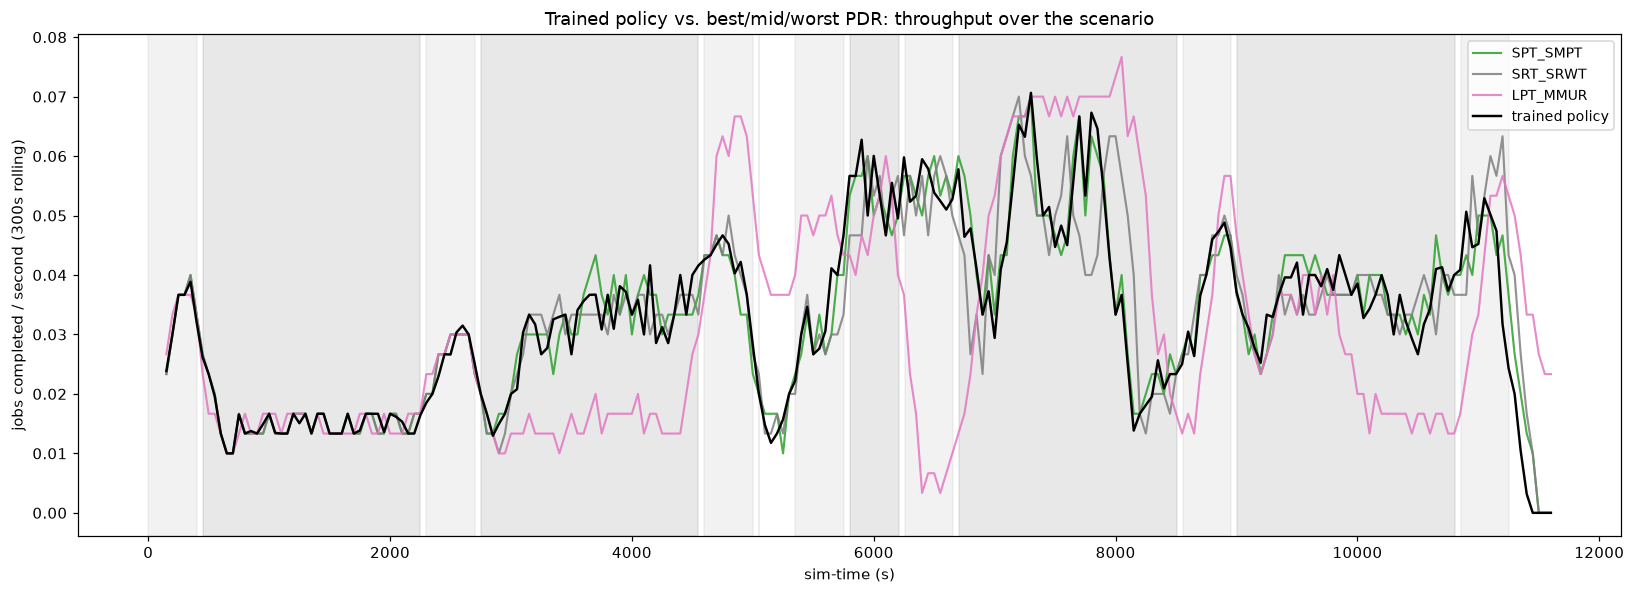

In [12]:

# jobs_exited is cumulative -- diff over a rolling window gives the same flow-rate view
# used for the PDRs above, computed straight from the decision log's own cumulative counter.
d = decisions.set_index("sim_time")["jobs_exited"]
window = 300.0
xs = np.arange(window / 2, t_max + 50, 50.0)
ys = np.interp(xs, d.index, d.values, left=0, right=d.values[-1])
ys_lo = np.interp(xs - window / 2, d.index, d.values, left=0, right=d.values[-1])
ys_hi = np.interp(xs + window / 2, d.index, d.values, left=0, right=d.values[-1])
throughput = (ys_hi - ys_lo) / window

fig, ax = plt.subplots(figsize=(15, 5.5))
for rule in ["SPT_SMPT", "SRT_SRWT", "LPT_MMUR"]:
    rows = first_seed_only(pdr_by_rule.get(rule, []))
    xs2, ys2 = rolling_throughput(rows, t_max)
    ax.plot(xs2, ys2, label=rule, color=COLORS[rule], linewidth=1.4, alpha=0.85)
ax.plot(xs, throughput, label="trained policy", color="black", linewidth=1.6)
shade_phases(ax, phases, max(throughput.max(), 0.15) * 1.05)
ax.set_xlabel("sim-time (s)"); ax.set_ylabel("jobs completed / second (300s rolling)")
ax.set_title("Trained policy vs. best/mid/worst PDR: throughput over the scenario")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()



**Quantitative comparison (9 held-out seeds 0-8, full scenario, not this notebook's single
fixed instance -- see `docs/RL_TRAINING_PIPELINE.md` §11 for the full per-seed table):**

| policy | makespan gap | total-flow gap to best PDR |
|---|---|---|
| SPT-SMPT (best PDR) | +0.01% | +0.00% |
| **trained checkpoint** | +0.01% | **+1.91%** |
| SRT-SRWT (mid PDR) | +0.03% | +7.57% |
| untrained init | +10.01% | +75.88% |
| LPT-MMUR (worst PDR) | +10.23% | +85.15% |

Aggregate gap-to-best-PDR progression across every run on this scenario: untrained 76% →
SHORT 44.6% → LONG 26.2% → **this policy 1.9%**. Beats best-PDR outright on 1/9 seeds,
beats the mid rule on 8/9 -- matched, not clearly beaten.



## D. What the trained policy is actually doing

Every decision's full action distribution was logged (`--decision-log`): which rule it
picked (argmax), how confident it was (`chosen_prob`), the distribution's entropy, and the
probability assigned to every one of the 9 rules. This is the direct evidence behind the
"matched, not exploited" reading from §11.


In [13]:

counts = decisions["rule"].value_counts()
print(counts)
print(f"\n{counts.iloc[0]}/{len(decisions)} decisions ({100*counts.iloc[0]/len(decisions):.1f}%) "
      f"chose '{counts.index[0]}'")


rule
SPT-SMPT     1158
FIFO-SRWT      28
Name: count, dtype: int64

1158/1186 decisions (97.6%) chose 'SPT-SMPT'


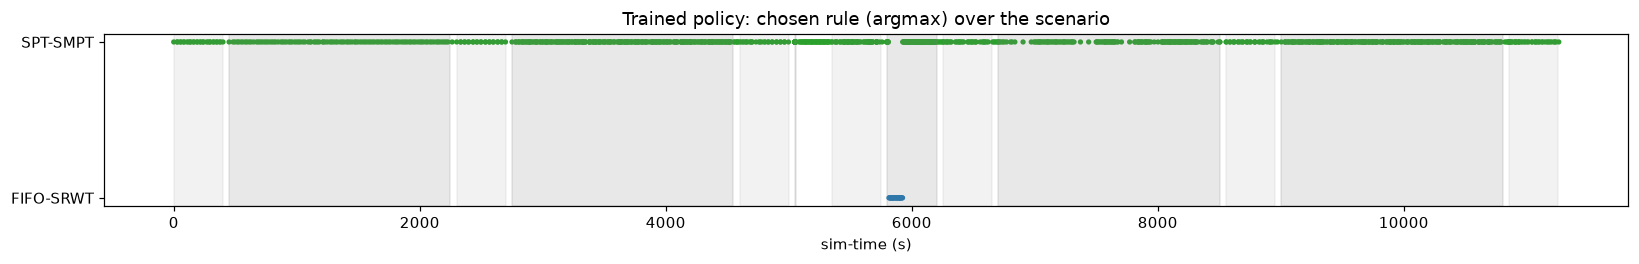

In [14]:

fig, ax = plt.subplots(figsize=(15, 2.5))
rule_to_y = {r: i for i, r in enumerate(sorted(decisions["rule"].unique()))}
colors_dash = [COLORS.get(r.replace("-", "_"), "black") for r in decisions["rule"]]
ax.scatter(decisions["sim_time"], decisions["rule"].map(rule_to_y), c=colors_dash, s=6)
shade_phases(ax, phases, len(rule_to_y) - 0.5)
ax.set_yticks(list(rule_to_y.values())); ax.set_yticklabels(list(rule_to_y.keys()))
ax.set_xlabel("sim-time (s)")
ax.set_title("Trained policy: chosen rule (argmax) over the scenario")
fig.tight_layout()
plt.show()


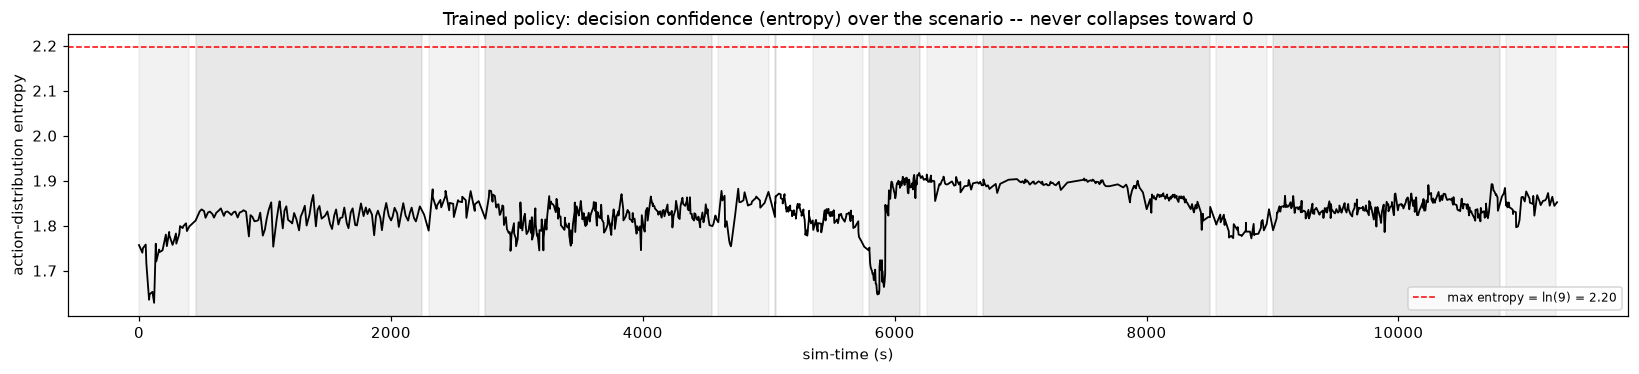

In [15]:

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.plot(decisions["sim_time"], decisions["entropy"], color="black", linewidth=1.2)
ax.axhline(np.log(9), color="red", linestyle="--", linewidth=1, label=f"max entropy = ln(9) = {np.log(9):.2f}")
shade_phases(ax, phases, np.log(9) * 1.05)
ax.set_xlabel("sim-time (s)"); ax.set_ylabel("action-distribution entropy")
ax.set_title("Trained policy: decision confidence (entropy) over the scenario -- "
             "never collapses toward 0")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()


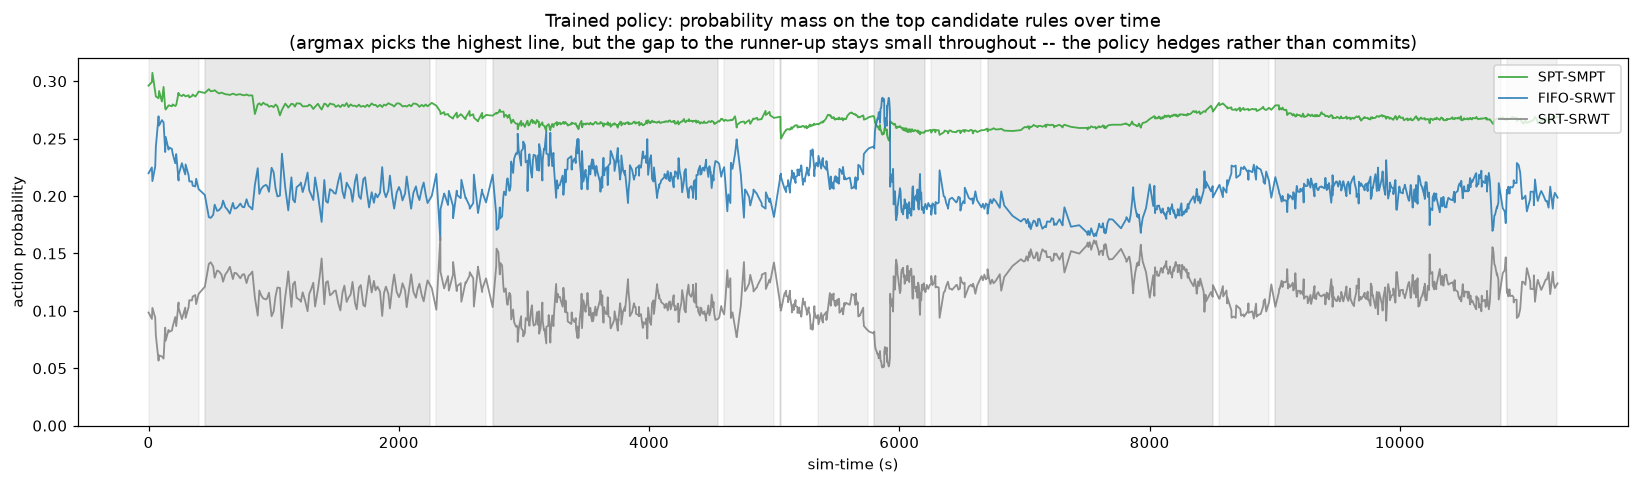

In [16]:

top_rules = decisions["rule"].value_counts().index[:2].tolist()
other_top = ["SRT-SRWT", "FIFO-SRWT", "SPT-SMPT"]
show_rules = list(dict.fromkeys(top_rules + [r for r in other_top if r not in top_rules]))[:4]

fig, ax = plt.subplots(figsize=(15, 4.5))
for r in show_rules:
    col = f"p_{r}"
    if col in decisions.columns:
        ax.plot(decisions["sim_time"], decisions[col], label=r,
                color=COLORS.get(r.replace("-", "_"), None), linewidth=1.2, alpha=0.85)
shade_phases(ax, phases, 1.0)
ax.set_xlabel("sim-time (s)"); ax.set_ylabel("action probability")
ax.set_ylim(0, None)
ax.set_title("Trained policy: probability mass on the top candidate rules over time\n"
             "(argmax picks the highest line, but the gap to the runner-up stays small "
             "throughout -- the policy hedges rather than commits)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()



**Summary:** the policy picked SPT-SMPT on the large majority of decisions -- essentially
learning to imitate the best PDR rather than discovering something that beats it outright
-- with a minority of decisions going to FIFO-SRWT. Chosen-action probability sits around
0.27-0.31 nearly everywhere, far from confident/deterministic, and the entropy trace never
drops meaningfully below its starting range. That's the concrete evidence for the
entropy-tuning hypothesis raised in `docs/RL_TRAINING_PIPELINE.md`'s open items: the
policy has learned roughly *which* rule is good, but hasn't learned to commit to it (or to
depart from it confidently when a different rule would do better) -- an exploitation gap,
not an exploration gap.

**One specific, non-trivial finding:** every one of the 28 FIFO-SRWT decisions falls in a
single tight window, sim-time 5815-5925s -- inside `starvation_1` (5800-6205s), and right
at its start, just after the 3 long jobs land and before the short-job stream fully takes
over. `starvation_1` is *specifically designed* to punish SPT-family rules: a continuous
short-job stream that outruns single-machine capacity means SPT/SRT rules defer the long
jobs for the entire stream (see §A's phase mechanics). The policy switching away from
SPT-SMPT exactly here, and only here, isn't noise -- it's evidence the network learned
something about *when* SPT-SMPT specifically fails, not just a generically-better-than-
untrained policy. That's a useful, concrete data point for the "did it learn real structure
or just memorize" question.



## E. `compound_scenario_v2`: does `speed_trap` actually separate the PDRs?

`compound_scenario_v2` adds two `speed_trap` phases (after each `standoff`) on top of
everything `compound_scenario` already had -- see `docs/RL_TRAINING_PIPELINE.md` §... for
the mechanism: unlike `standoff`'s per-job-randomized cost gap (which self-balances load
under greedy routing), `speed_trap`'s gap is *consistent* across every job, so a routing
rule that always greedily picks the genuinely-faster machine (SMPT) funnels the whole
stream onto one machine while the other sits idle -- the first tested regime where
SPT-SMPT, the rule that otherwise wins or ties almost everywhere in `compound_scenario`,
should lose outright. Same batch-runner data source and plotting functions as §B, now
pointed at `results/static_pdrs/0918a` (9 rules incl. random, 3 repeats, 533 jobs, 17
phases, ~15,855s).


In [17]:

scenario_v2 = json.load(open(REPO_ROOT / "linux_server/BatchConfigs/Scenarios/compound_scenario_v2.json"))
phases_v2 = scenario_v2["_phases"]
t_max_v2 = phases_v2[-1]["end"] + 300.0

pdr_rows_v2 = load_job_completions(REPO_ROOT / "results/static_pdrs/0918a", instance_name="compound_scenario_v2")
pdr_by_rule_v2 = defaultdict(list)
for r in pdr_rows_v2:
    pdr_by_rule_v2[r["rule"]].append(r)
print({rule: len(first_seed_only(pdr_by_rule_v2.get(rule, []))) for rule in RULES_ORDER})


{'FIFO_SRWT': 533, 'SPT_SRWT': 533, 'SPT_SMPT': 533, 'LPT_SMPT': 533, 'LRT_MMUR': 533, 'LPT_MMUR': 533, 'SRT_SRWT': 533, 'SRT_SMPT': 533, 'random': 533}


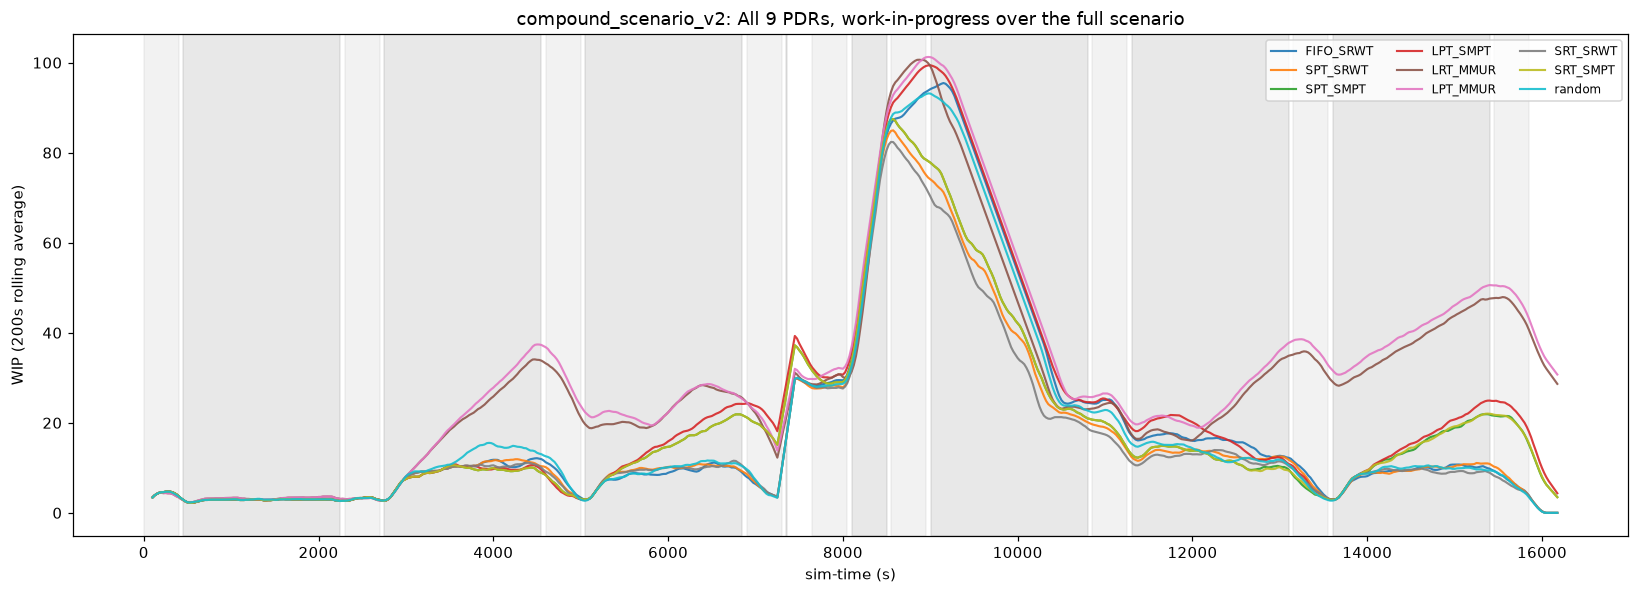

In [18]:

plot_overlay(pdr_by_rule_v2, phases_v2, t_max_v2, rolling_wip,
             ylabel="WIP (200s rolling average)",
             title="compound_scenario_v2: All 9 PDRs, work-in-progress over the full scenario")


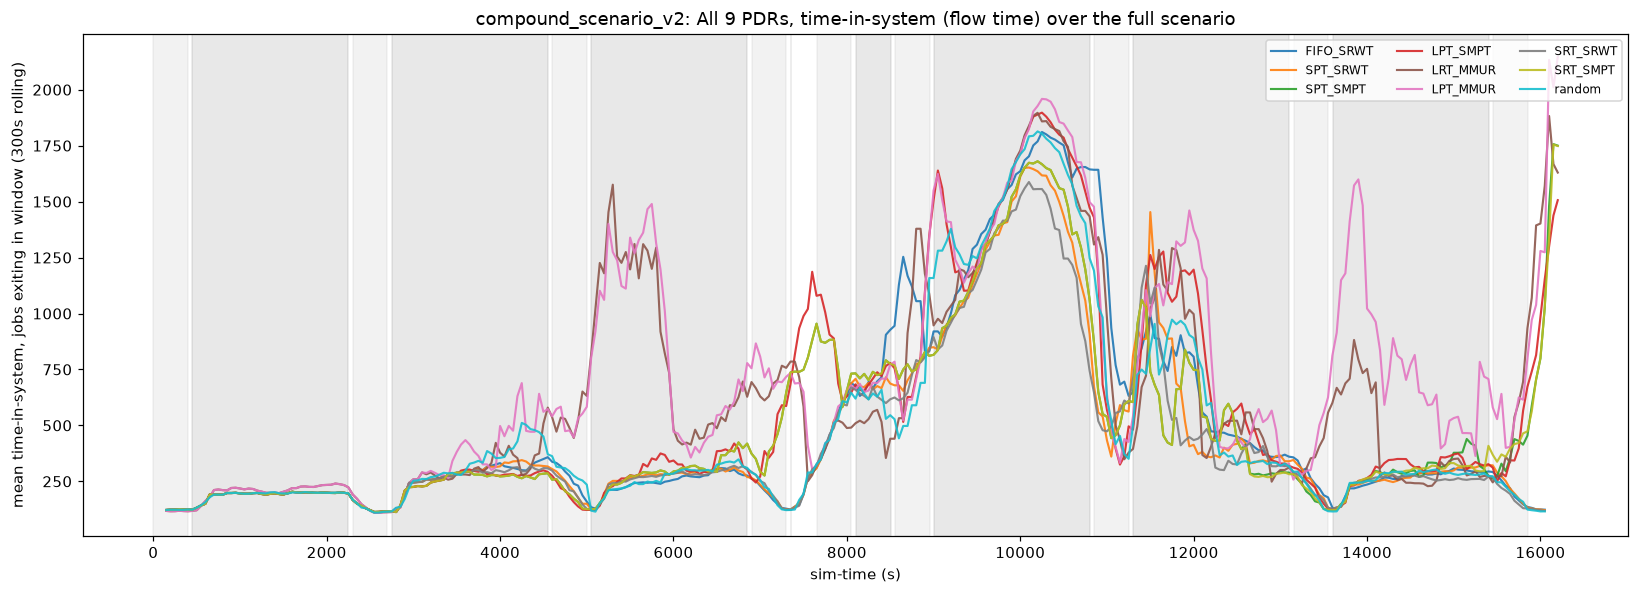

In [19]:

plot_overlay(pdr_by_rule_v2, phases_v2, t_max_v2, rolling_flowtime,
             ylabel="mean time-in-system, jobs exiting in window (300s rolling)",
             title="compound_scenario_v2: All 9 PDRs, time-in-system (flow time) over the full scenario")


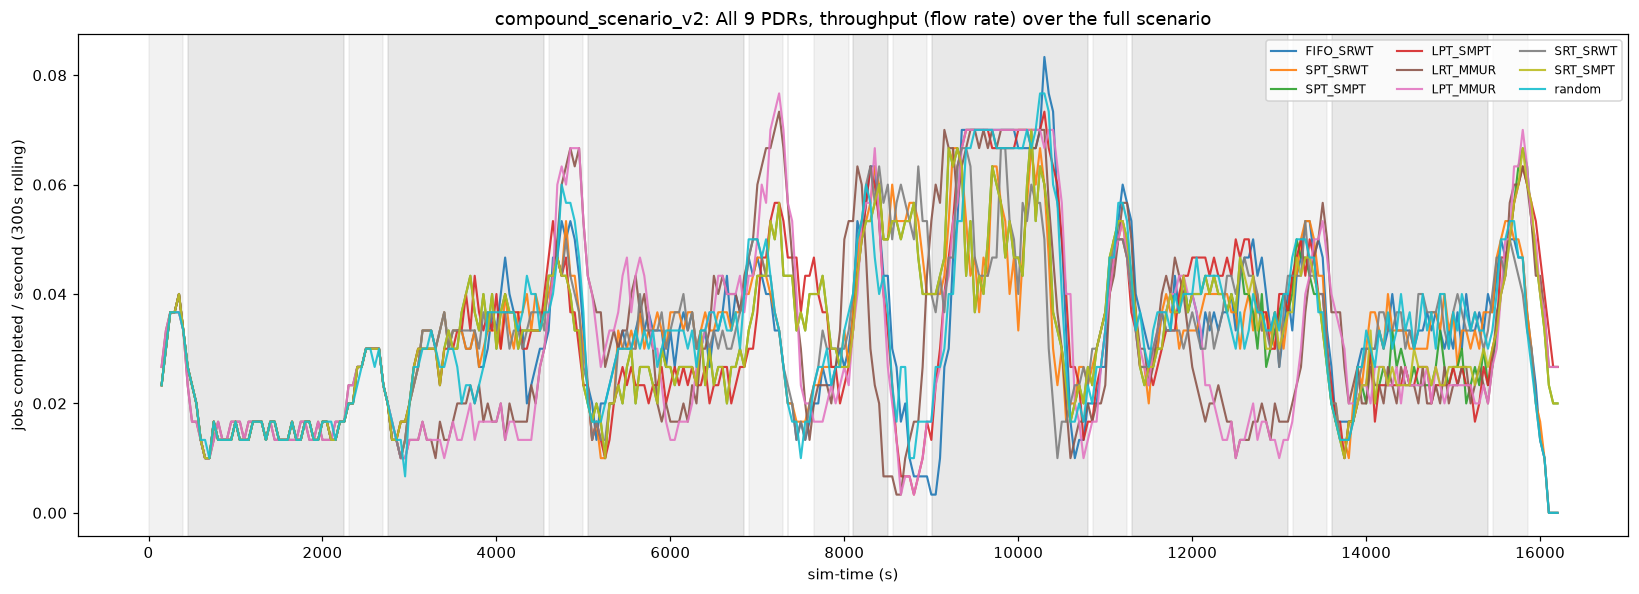

In [20]:

plot_overlay(pdr_by_rule_v2, phases_v2, t_max_v2, rolling_throughput,
             ylabel="jobs completed / second (300s rolling)",
             title="compound_scenario_v2: All 9 PDRs, throughput (flow rate) over the full scenario")


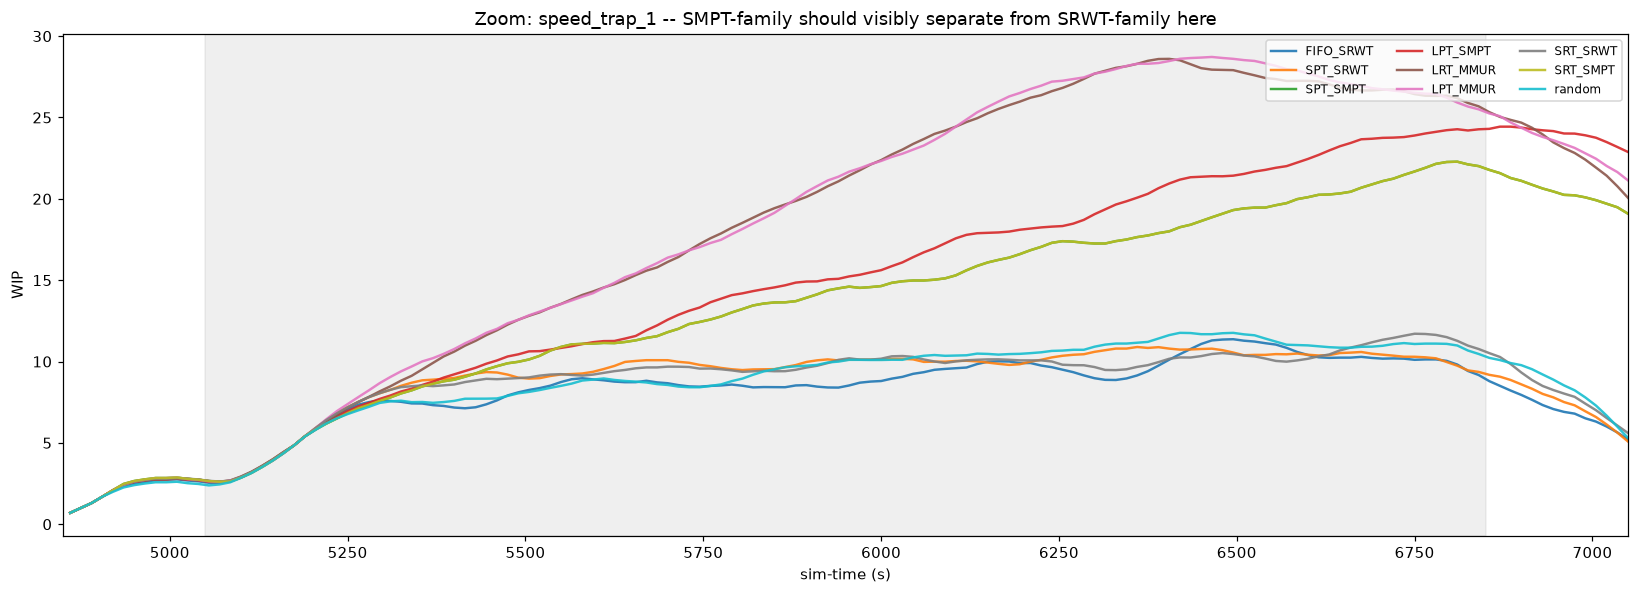

In [21]:

# Zoom on speed_trap_1 specifically -- the new regime, isolated from everything else
st1 = next(p for p in phases_v2 if p["name"] == "speed_trap_1")
window_lo, window_hi = st1["start"] - 200, st1["end"] + 200

fig, ax = plt.subplots(figsize=(15, 5.5))
y_max = 0
for rule in RULES_ORDER:
    rows = [r for r in first_seed_only(pdr_by_rule_v2.get(rule, [])) if window_lo <= r["arrival"] <= window_hi]
    if not rows:
        continue
    xs, ys = rolling_wip(rows, window_hi, window=150.0, step=15.0)
    mask = xs >= window_lo
    ax.plot(xs[mask], ys[mask], label=rule, color=COLORS[rule], linewidth=1.6, alpha=0.9)
    finite = ys[mask][np.isfinite(ys[mask])]
    if finite.size:
        y_max = max(y_max, finite.max())
ax.axvspan(st1["start"], st1["end"], color="gray", alpha=0.12)
ax.set_xlim(window_lo, window_hi)
ax.set_xlabel("sim-time (s)"); ax.set_ylabel("WIP")
ax.set_title("Zoom: speed_trap_1 -- SMPT-family should visibly separate from SRWT-family here")
ax.legend(loc="upper right", fontsize=8, ncol=3)
fig.tight_layout()
plt.show()


In [22]:

# Per-rule mean flow time within speed_trap phases specifically (both occurrences pooled)
st_names = {"speed_trap_1", "speed_trap_2"}
st_windows = [(p["start"], p["end"]) for p in phases_v2 if p["name"] in st_names]

def in_speed_trap(t):
    return any(lo <= t < hi for lo, hi in st_windows)

means = {}
for rule in RULES_ORDER:
    rows = [r for r in pdr_rows_v2 if r["rule"] == rule and r["exit"] is not None and in_speed_trap(r["arrival"])]
    if rows:
        means[rule] = sum(r["flow"] for r in rows) / len(rows)

best = min(means.values())
print(f"{'rule':<12}{'mean_flow':>12}{'gap_to_best':>14}")
for rule, m in sorted(means.items(), key=lambda kv: kv[1]):
    print(f"{rule:<12}{m:>12.1f}{100*(m-best)/best:>13.1f}%")


rule           mean_flow   gap_to_best
SRT_SRWT           267.5          0.0%
FIFO_SRWT          273.6          2.3%
SPT_SRWT           278.8          4.2%
random             284.1          6.2%
SRT_SMPT           551.4        106.2%
SPT_SMPT           553.9        107.1%
LPT_SMPT           615.9        130.3%
LRT_MMUR           892.8        233.8%
LPT_MMUR          1035.5        287.1%



**Reading this:** if the mechanism holds at the full-scenario scale (not just the isolated
63-job `speed_trap_standoff` test), the -SMPT rules (SPT/LPT/SRT_SMPT) should cluster at
the worst mean flow time within the `speed_trap` windows specifically, -SRWT rules at the
best, with -MMUR in between -- the same tiering `speed_trap_standoff` showed in isolation,
now embedded in the full 17-phase cycle alongside everything `compound_scenario` already
tests. This is the evidence for whether training on `compound_scenario_v2` should actually
teach the policy to leave SPT-SMPT more often than it currently does (§D).
